# __Census Data Modelling Practice For Adelaide CBD / North Adelaide__

Goal is to put census data into the node network. tables-formatted contains Mesh Block codes with method of transport counts and also DZN codes for people's POW with counts of different occupations.

In [1]:
import sys
!{sys.executable} -m pip install --quiet osmnx networkx matplotlib

In [2]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd

ox.settings.log_console = True
ox.settings.use_cache = True

__*Define Area using OSM's relation for the entire Central Adelaide LGA 3093825*__

In [3]:
gdf_boundary = ox.geocode_to_gdf("R3093825", by_osmid=True)
polygon = gdf_boundary.geometry.iloc[0]

G = ox.graph_from_polygon(polygon, network_type="bike")
print(f"Nodes: {len(G.nodes)}. Edges: {len(G.edges)}")

Nodes: 3687. Edges: 8251


In [4]:
print(gdf_boundary.display_name[0])

Adelaide City Council, South Australia, Australia


# Adelaide City Node Network

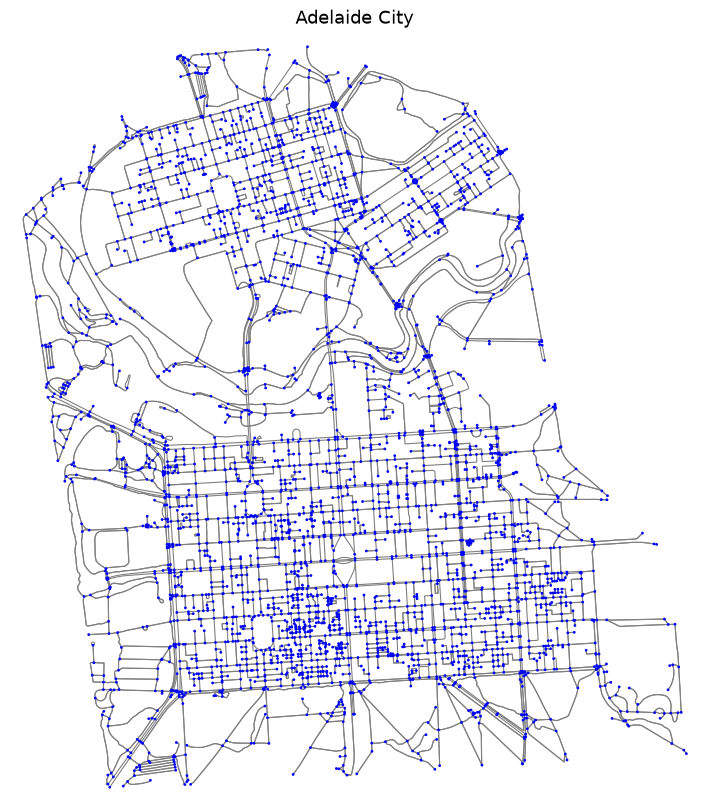

In [5]:
fig, ax = ox.plot_graph(
    G,
    node_size=4,
    node_color="blue",
    node_zorder=3,
    edge_color="gray",
    edge_linewidth=0.8,
    bgcolor="white",
    figsize=(10, 10),
    show=False,
    close=False,
)
ax.set_title("Adelaide City", fontsize=13)
plt.show()

__*Load in all of the mesh blocks and destination zones*__

In [18]:
all_mesh_blocks = gpd.read_file("../australia-mesh-blocks-raw/MB_2021_AUST_GDA2020.shp")
all_destination_zones = gpd.read_file("../australia-destination-zones-raw/DZN_2021_AUST_GDA2020.shp")

__*match crs and clip*__

In [19]:
mb_gdf_boundary_crs = gdf_boundary.to_crs(all_mesh_blocks.crs)
mesh_blocks_adl = gpd.clip(all_mesh_blocks, mb_gdf_boundary_crs)
dzn_gdf_boundary_crs = gdf_boundary.to_crs(all_destination_zones.crs)
destination_zones_adl = gpd.clip(all_destination_zones, dzn_gdf_boundary_crs)

*Test counts*

In [20]:
print('MB all count: ', len(all_mesh_blocks))
print('MB Adelaide count: ', len(mesh_blocks_adl))
print('DZN all count: ', len(all_destination_zones))
print('DZN Adelaide count: ', len(destination_zones_adl))

MB all count:  368286
MB Adelaide count:  589
DZN all count:  9329
DZN Adelaide count:  33


__*Load Mesh Blocks and Destination Zones into graph*__

In [22]:
import networkx as nx

# Join each graph node to its mesh block and destination zone.
nodes_gdf = ox.graph_to_gdfs(G, nodes=True, edges=False)[["geometry"]]

nodes_mesh_blocks = gpd.sjoin(
    nodes_gdf.to_crs(mesh_blocks_adl.crs),
    mesh_blocks_adl[["MB_CODE21", "geometry"]],
    how="left",
    predicate="within",
)
node_mb_codes = nodes_mesh_blocks["MB_CODE21"].dropna().to_dict()
nx.set_node_attributes(G, node_mb_codes, "MB_CODE21")

nodes_destination_zones = gpd.sjoin(
    nodes_gdf.to_crs(destination_zones_adl.crs),
    destination_zones_adl[["DZN_CODE21", "geometry"]],
    how="left",
    predicate="within",
)
node_dzn_codes = nodes_destination_zones["DZN_CODE21"].dropna().to_dict()
nx.set_node_attributes(G, node_dzn_codes, "DZN_CODE21")

print(f"Graph nodes: {len(G.nodes)}")
print(f"Nodes with MB_CODE21: {len(node_mb_codes)}")
print(f"Nodes with DZN_CODE21: {len(node_dzn_codes)}")

Graph nodes: 3687
Nodes with MB_CODE21: 3687
Nodes with DZN_CODE21: 3687


# __Importing CSV Data Into the Project__

I have two tables to practice with:

`tables-formatted/transport-mode-MB` gives the count of each preferred mode of transport for each mesh block in the adelaide city zone. The mesh blocks are by usual residence.

`tables-formatted/POW-occupation-DZN` gives the count of each occupation type for each destination zone. The destination zone of each data point is that person's place of work.

__*Read the transport modes data into the table*__

For this model I'm only interested in the 'bicycle' column so this is the only variable I'll be injecting into the graph.

In [ ]:
import csv

transport_mode_path = "tables-formatted/transport-mode-MB.csv"
with open(transport_mode_path, newline="") as csv_file:
    reader = csv.DictReader(csv_file)
    mb_code_col = reader.fieldnames[0] if reader.fieldnames else None
    rows = list(reader)

if mb_code_col is None or not rows or "Bicycle" not in rows[0]:
    raise ValueError("The transport CSV must contain a mesh-block code column and a Bicycle column.")

bicycle_by_mb = {
    str(row[mb_code_col]).strip(): int(row["Bicycle"])
    for row in rows
    if row[mb_code_col].strip() != "Total"
}

nodes_with_bicycle_data = 0
for node_id, node_data in G.nodes(data=True):
    mb_code = str(node_data["MB_CODE21"])
    if mb_code in bicycle_by_mb:
        nodes_with_bicycle_data += 1
    node_data["N_CYCLIST_COMMUTERS_MB"] = bicycle_by_mb.get(mb_code, 0)

print(f"Nodes with Bicycle data: {nodes_with_bicycle_data} / {len(G.nodes)}")
print(f"Nodes without Bicycle data: {len(G.nodes) - nodes_with_bicycle_data}")

Nodes with Bicycle data: 3687 / 3687
Nodes without Bicycle data: 0


__*Read the DZN occupation count data into the table*__

In [23]:
occupation_dzn_path = "tables-formatted/POW-occupation-DZN.csv"
with open(occupation_dzn_path, newline="") as csv_file:
    reader = csv.DictReader(csv_file)
    dzn_code_col = reader.fieldnames[0] if reader.fieldnames else None
    rows = list(reader)

office_worker_columns = [
    "Managers",
    "Professionals",
    "Clerical and Administrative Workers",
    "Sales Workers",
]
required_columns = office_worker_columns + ["Total"]
if (
    dzn_code_col is None
    or not rows
    or any(column not in rows[0] for column in required_columns)
):
    raise ValueError("The occupation CSV is missing a required column.")

def normalize_code(code):
    code_text = str(code).strip()
    return code_text[:-2] if code_text.endswith(".0") else code_text

percentage_office_workers_by_dzn = {
    normalize_code(row[dzn_code_col]): float(
        f"{sum(int(row[column]) for column in office_worker_columns) / int(row['Total']):.2g}"
    )
    if int(row["Total"]) > 0
    else 0.0
    for row in rows
    if normalize_code(row[dzn_code_col]) != "Total"
}

nodes_with_occupation_data = 0
for node_id, node_data in G.nodes(data=True):
    dzn_code = normalize_code(node_data["DZN_CODE21"])
    if dzn_code in percentage_office_workers_by_dzn:
        nodes_with_occupation_data += 1
    node_data["PERCENTAGE_OFFICE_WORKERS"] = percentage_office_workers_by_dzn.get(dzn_code, 0.0)

print(f"Nodes with occupation data: {nodes_with_occupation_data} / {len(G.nodes)}")
print(f"Nodes without occupation data: {len(G.nodes) - nodes_with_occupation_data}")

Nodes with occupation data: 3687 / 3687
Nodes without occupation data: 0


# Adelaide City Coloured Node Network

Colours will be assigned to nodes and edges based on the data inserted. Nodes will be marked like a heatmap, where a node is closer to red when N_CYCLIST_COMMUTERS_MB is higher or when PERCENTAGE_OFFICE_WORKERS is high.

__*Assign Final Node Score*__

In [26]:
for node_id, node_data in G.nodes(data=True):
    node_data["SCORE"] = (
        40 * node_data["PERCENTAGE_OFFICE_WORKERS"]
        + 10 * node_data["N_CYCLIST_COMMUTERS_MB"]
    )

__*Assign Node and Edge Colour*__
Node colour is based on score. Edge colour will take the average of its related nodes.

In [27]:
import matplotlib.colors as mcolors

node_scores = [node_data["SCORE"] for _, node_data in G.nodes(data=True)]
score_min = min(node_scores)
score_max = max(node_scores)
score_norm = mcolors.Normalize(vmin=score_min, vmax=score_max or score_min + 1)
score_cmap = plt.cm.coolwarm

node_colors = [
    mcolors.to_hex(score_cmap(score_norm(node_data["SCORE"])))
    for _, node_data in G.nodes(data=True)
]

edge_colors = []
for source, target, edge_data in G.edges(data=True):
    edge_score = (G.nodes[source]["SCORE"] + G.nodes[target]["SCORE"]) / 2
    edge_colors.append(mcolors.to_hex(score_cmap(score_norm(edge_score))))

print(f"Score range: {score_min:.2f} to {score_max:.2f}")
print(f"Node colours: {len(node_colors)}")
print(f"Edge colours: {len(edge_colors)}")

Score range: 10.80 to 110.00
Node colours: 3687
Edge colours: 8251


__*Plot Graph*__

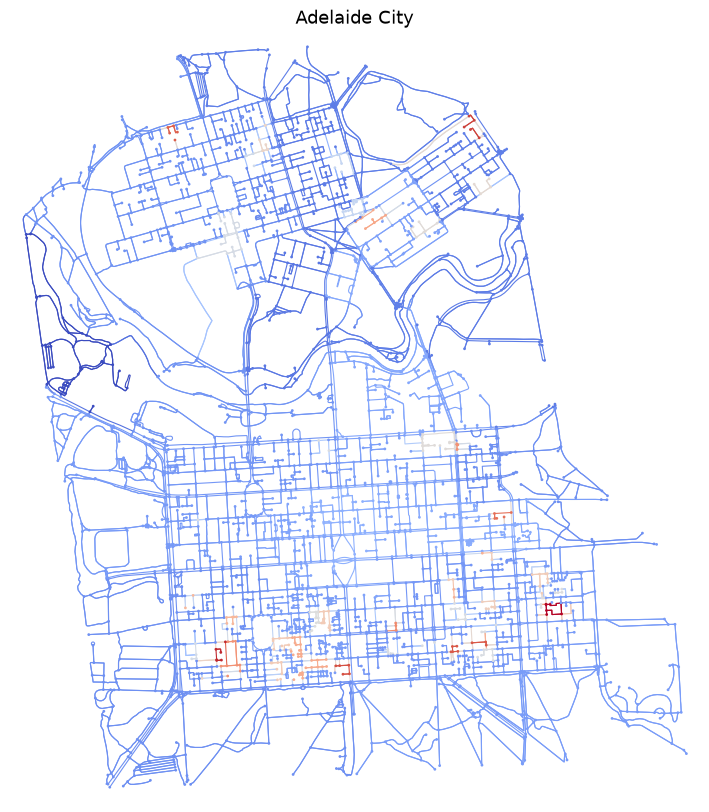

In [28]:
fig, ax = ox.plot_graph(
    G,
    node_size=4,
    node_color=node_colors,
    node_zorder=3,
    edge_color=edge_colors,
    edge_linewidth=0.8,
    bgcolor="white",
    figsize=(10, 10),
    show=False,
    close=False,
 )
ax.set_title("Adelaide City", fontsize=13)
plt.show()